U-Net model

In [ ]:
import kagglehub

path = kagglehub.dataset_download("bulentsiyah/semantic-drone-dataset")
print("Dataset path:", path)

100%|██████████| 3.89G/3.89G [04:28<00:00, 15.6MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/bulentsiyah/semantic-drone-dataset/versions/6


In [ ]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    break

/root/.cache/kagglehub/datasets/bulentsiyah/semantic-drone-dataset/versions/6


In [ ]:
!pip install segmentation_models_pytorch
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.6 MB/s eta 0:00:00


Auto-Detect Image & Mask Folders

In [ ]:
def find_folder(base_path, keyword):
    for root, dirs, files in os.walk(base_path):
        for d in dirs:
            if keyword.lower() in d.lower():
                return os.path.join(root, d)
    return None

# Explicitly set the correct image and mask directories based on dataset structure
img_dir = os.path.join(path, "dataset", "semantic_drone_dataset", "original_images")
mask_dir = os.path.join(path, "dataset", "semantic_drone_dataset", "label_images_semantic")

print("Image Directory:", img_dir)
print("Mask Directory:", mask_dir)

Image Directory: /root/.cache/kagglehub/datasets/bulentsiyah/semantic-drone-dataset/versions/6/dataset/semantic_drone_dataset/original_images
Mask Directory: /root/.cache/kagglehub/datasets/bulentsiyah/semantic-drone-dataset/versions/6/dataset/semantic_drone_dataset/label_images_semantic


In [ ]:
print("Number of Images:", len(os.listdir(img_dir)))
print("Number of Masks:", len(os.listdir(mask_dir)))

print("Sample Images:", os.listdir(img_dir)[:5])
print("Sample Masks:", os.listdir(mask_dir)[:5])

Number of Images: 1
Number of Masks: 400
Sample Images: ['RGB_color_image_masks']
Sample Masks: ['001.png', '018.png', '509.png', '041.png', '316.png']


In [ ]:
def get_mask_name(img_name):
    if img_name.endswith(".jpg"):
        return img_name.replace(".jpg", ".png")
    elif img_name.endswith(".jpeg"):
        return img_name.replace(".jpeg", ".png")
    return img_name

Visualize Sample

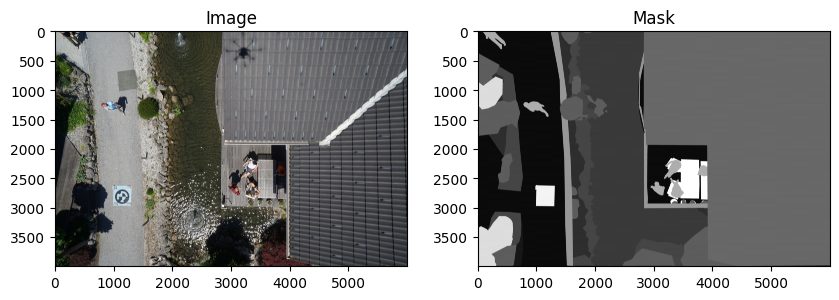

In [ ]:
images = os.listdir(img_dir)

img_path = os.path.join(img_dir, images[0])
mask_path = os.path.join(mask_dir, get_mask_name(images[0]))

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, 0)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask")

plt.show()

In [ ]:
transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.Normalize(),
    ToTensorV2()
])

Custom Dataset Class

In [ ]:
class DroneDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = os.listdir(img_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.img_dir, img_name)
        mask_name = get_mask_name(img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = cv2.imread(img_path)
        mask = cv2.imread(mask_path, 0)

        if image is None or mask is None:
            raise ValueError(f"Error loading {img_name}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        return image, mask.long()

DataLoader

In [ ]:
dataset = DroneDataset(img_dir, mask_dir, transform=transform)
train_loader = DataLoader(dataset, batch_size=4, shuffle=True)

Model (U-Net)

In [ ]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=23
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Training Setup

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Training Loop

In [ ]:
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = loss_fn(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

Epoch 1, Loss: 1.8408528852462769
Epoch 2, Loss: 1.440727247595787
Epoch 3, Loss: 1.3398905527591705
Epoch 4, Loss: 1.2419850844144822
Epoch 5, Loss: 1.180094100832939


IoU Score

In [ ]:
def iou_score(pred, target, num_classes=23):
    pred = torch.argmax(pred, dim=1)

    iou = 0
    count = 0

    for cls in range(num_classes):
        pred_inds = (pred == cls)
        target_inds = (target == cls)

        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()

        if union == 0:
            continue

        iou += intersection / union
        count += 1

    return iou / count if count > 0 else 0

Prediction Visualization

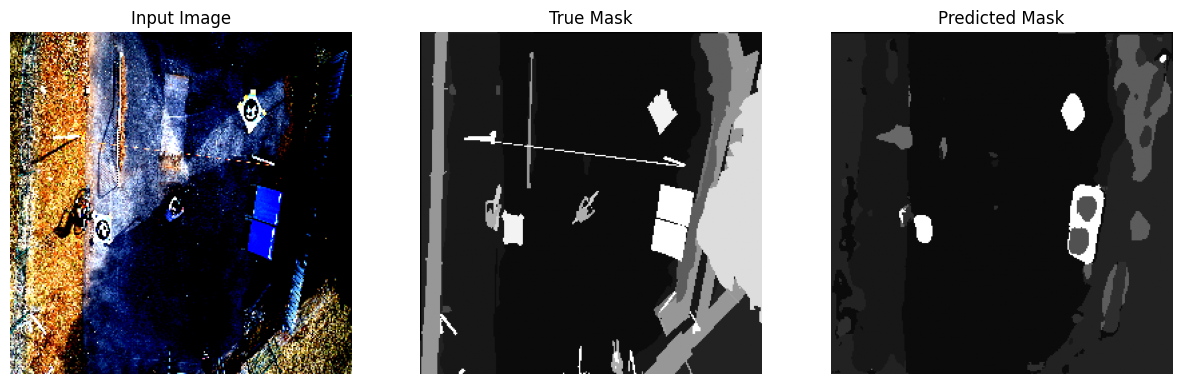

In [52]:
import matplotlib.pyplot as plt

model.eval()

images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    preds = model(images)

preds = torch.argmax(preds, dim=1)

# Move to CPU
images = images.cpu()
masks = masks.cpu()
preds = preds.cpu()

# Plot 3 columns: Input | True Mask | Predicted Mask
plt.figure(figsize=(15,5))

# Input Image
plt.subplot(1,3,1)
plt.imshow(images[0].permute(1,2,0))
plt.title("Input Image")
plt.axis("off")

# True Mask
plt.subplot(1,3,2)
plt.imshow(masks[0], cmap='gray')
plt.title("True Mask")
plt.axis("off")

# Predicted Mask
plt.subplot(1,3,3)
plt.imshow(preds[0], cmap='gray')
plt.title("Predicted Mask")
plt.axis("off")

plt.show()